# Decision Tree Analysis

This notebook loads the SOC dataset, preprocesses the features, trains a Decision Tree classifier, evaluates the model, and saves the trained model to a joblib file.

In [7]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib

In [8]:
DATA_FILE = os.path.join('Datasets', 'part-00000-0af89d10-df53-44fd-b124-a8a496fd5023-c000(2).csv')
df = pd.read_csv(DATA_FILE)
print(f'Loaded {len(df)} rows with columns: {list(df.columns)}')
df.head()

Loaded 23003 rows with columns: ['resp_pkts', 'service', 'orig_ip_bytes', 'local_resp', 'missed_bytes', 'protocol', 'duration', 'conn_state', 'dest_ip', 'orig_pkts', 'community_id', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'local_orig', 'datetime', 'history', 'resp_bytes', 'uid', 'src_port', 'ts', 'src_ip', 'mitre_attack_tactics']


,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,dest_ip,orig_pkts,...,orig_bytes,local_orig,datetime,history,resp_bytes,uid,src_port,ts,src_ip,mitre_attack_tactics
0,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance
1,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance
2,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance
3,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance
4,2,dns,186,False,0,udp,0.00228,SF,143.88.5.1,2,...,130.0,False,2022-02-10T03:58:29.979Z,Dd,130.0,CwO2bA321vyBxBjtxb,36073,1.644466e+09,143.88.5.12,Reconnaissance


In [9]:
def preprocess(df):
    drop_columns = ['uid', 'community_id', 'datetime', 'src_ip', 'dest_ip', 'ts']
    df = df.drop(columns=[col for col in drop_columns if col in df.columns], errors='ignore')
    target_column = 'mitre_attack_tactics'
    y = df[target_column].astype(str)
    X = df.drop(columns=[target_column])
    encoders = {}
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]) or pd.api.types.is_bool_dtype(X[col]):
            encoder = LabelEncoder()
            X[col] = encoder.fit_transform(X[col].astype(str))
            encoders[col] = encoder
    target_encoder = LabelEncoder()
    y_encoded = target_encoder.fit_transform(y)
    encoders[target_column] = target_encoder
    return X, y_encoded, encoders

X, y, encoders = preprocess(df)
print('Feature dtypes after preprocessing:')
print(X.dtypes)
print('Target classes:')
print(encoders['mitre_attack_tactics'].classes_)

Feature dtypes after preprocessing:
resp_pkts          int64
service            int64
orig_ip_bytes      int64
local_resp         int64
missed_bytes       int64
protocol           int64
duration         float64
conn_state         int64
orig_pkts          int64
resp_ip_bytes      int64
dest_port          int64
orig_bytes       float64
local_orig         int64
history            int64
resp_bytes       float64
src_port           int64
dtype: object
Target classes:
['Reconnaissance' 'none']


Accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1152
           1       1.00      1.00      1.00      4599

    accuracy                           1.00      5751
   macro avg       1.00      1.00      1.00      5751
weighted avg       1.00      1.00      1.00      5751

Confusion matrix:
[[1152    0]
 [   0 4599]]
Feature importances:
  duration: 0.7256
  orig_ip_bytes: 0.2664
  orig_bytes: 0.0043
  dest_port: 0.0036
  src_port: 0.0000
  resp_pkts: 0.0000
  service: 0.0000
  local_resp: 0.0000
  missed_bytes: 0.0000
  protocol: 0.0000
  conn_state: 0.0000
  orig_pkts: 0.0000
  resp_ip_bytes: 0.0000
  local_orig: 0.0000
  history: 0.0000
  resp_bytes: 0.0000


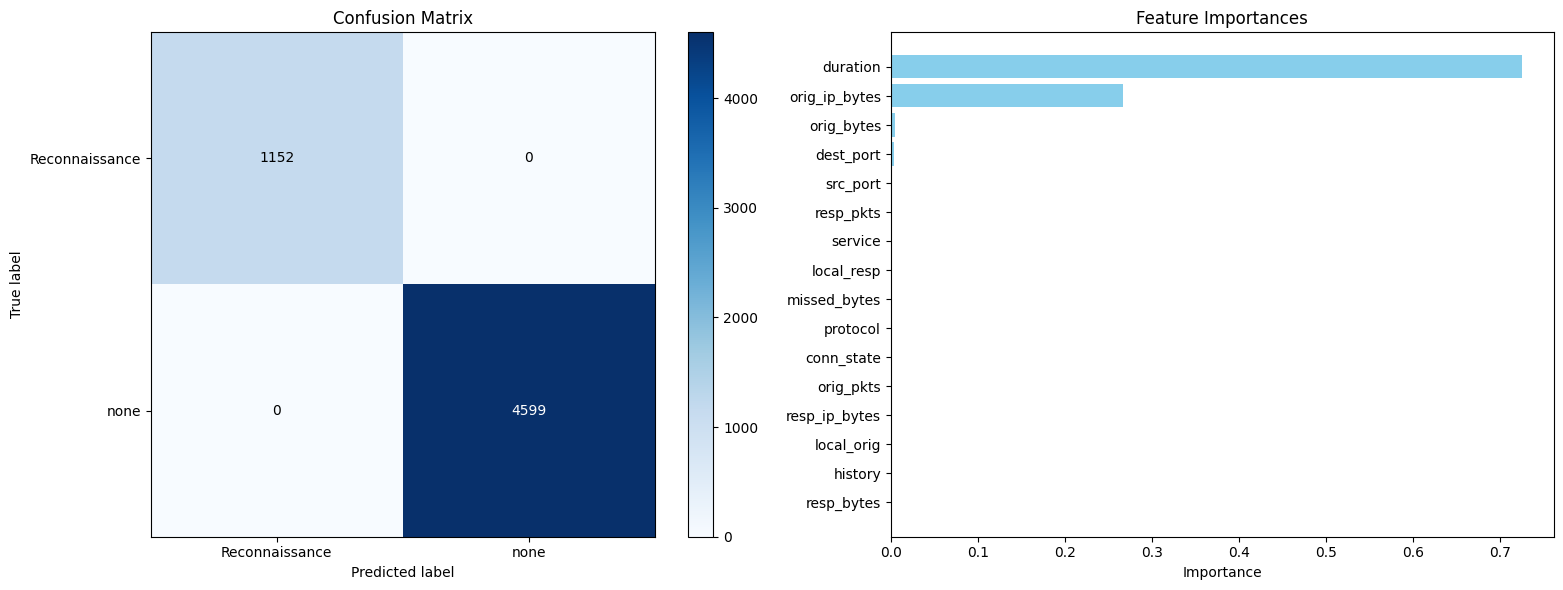

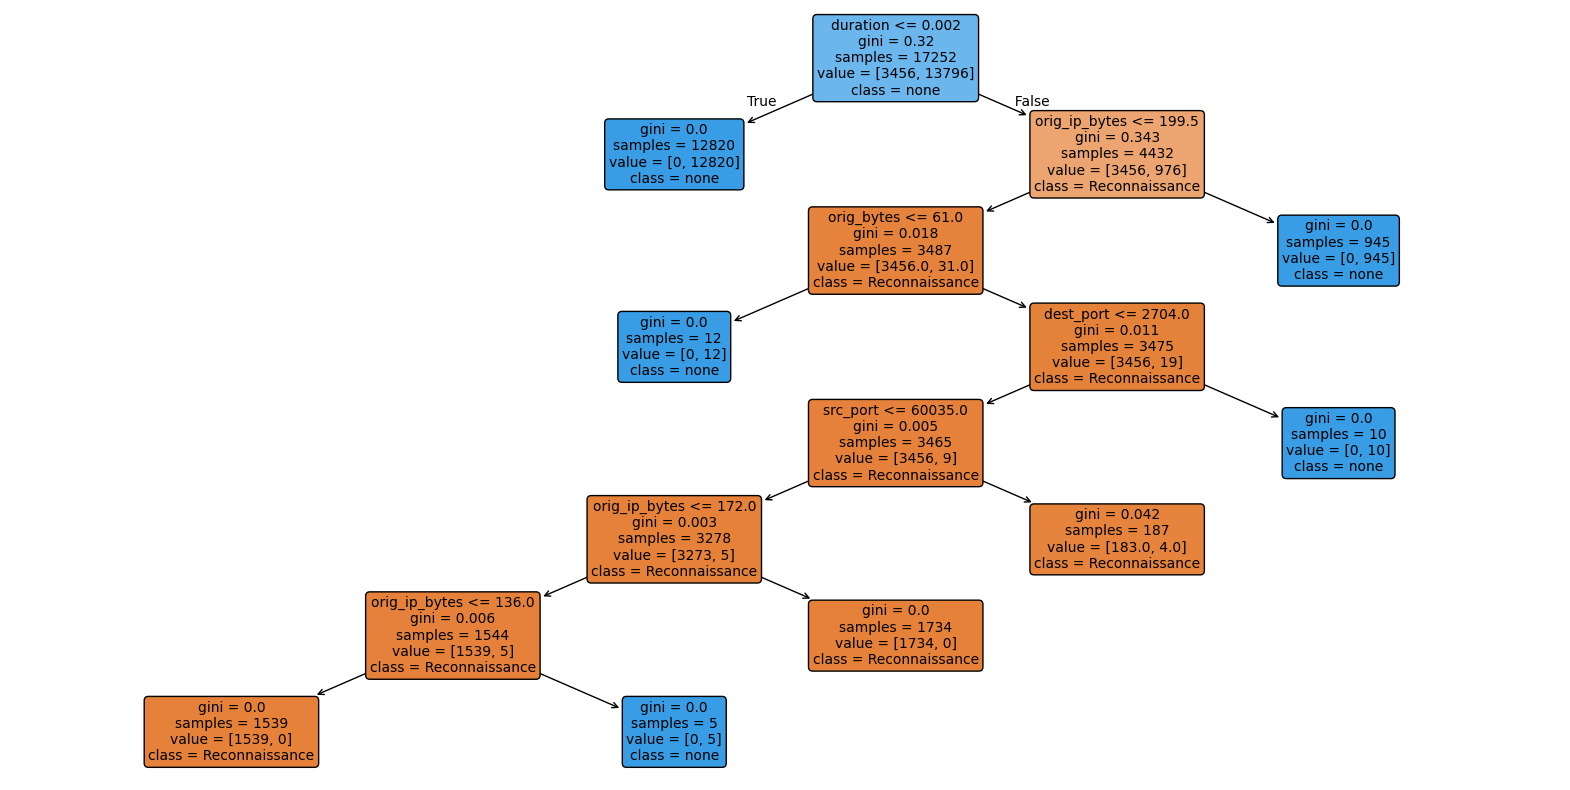

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification report:')
print(classification_report(y_test, y_pred, zero_division=0))
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
print(cm)
importances = sorted(zip(X.columns, model.feature_importances_), key=lambda x: x[1], reverse=True)
print('Feature importances:')
for feature, importance in importances:
    print(f'  {feature}: {importance:.4f}')

# Visualize the confusion matrix and feature importances
classes = encoders['mitre_attack_tactics'].classes_
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.colorbar(im, ax=ax)

ax2 = axes[1]
features = [feature for feature, _ in importances]
scores = [importance for _, importance in importances]
ax2.barh(features[::-1], scores[::-1], color='skyblue')
ax2.set_title('Feature Importances')
ax2.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Plot the decision tree structure as well
try:
    fig2, ax3 = plt.subplots(figsize=(20, 10))
    plot_tree(model, feature_names=X.columns, class_names=classes, filled=True, rounded=True, fontsize=10, ax=ax3)
    plt.show()
except Exception as exc:
    print('Decision tree plot failed:', exc)

In [11]:
model_path = 'decision_tree_model.joblib'
joblib.dump(model, model_path)
print(f'Saved trained model to {model_path}')
# Optionally save the label encoder for the target as well
joblib.dump(encoders['mitre_attack_tactics'], 'target_encoder.joblib')
print('Saved target label encoder to target_encoder.joblib')

Saved trained model to decision_tree_model.joblib
Saved target label encoder to target_encoder.joblib
